In [ ]:
# Jupyter notebooks have problems with imports from parent folder, so let's change the path
from jupyter_utils import change_path_to_parent
change_path_to_parent()

import matplotlib
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt
%load_ext autoreload
%autoreload 2
from optmethods.first_order import AdgdAccel
from optmethods.datasets import get_dataset


from optmethods.loss import LogisticRegression, LogSumExp
from optmethods.second_order import Newton
from optmethods.second_order import CaCuAdGD
from optmethods.second_order import Cubic, AccCubic, SuperCubic
from optmethods.second_order import CaCuN, AccCaCuN
from optmethods.second_order import Arc, Cubic, Newton, RegNewton
from optmethods.quasi_newton import Bfgs, Dfp, Lbfgs, Sr1, Shorr
from optmethods.first_order import Adgd, AdgdAccel, Gd, Nesterov, Ogm, Polyak, RestNest
from optmethods.utils import get_trace, relative_round

sns.set(style="whitegrid", context="talk", palette=sns.color_palette("bright"), color_codes=False)
matplotlib.rc('font', family='sans-serif') 
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
matplotlib.rcParams['mathtext.fontset'] = 'cm'
matplotlib.rcParams['figure.figsize'] = (9, 6)

markers = ['s', 'o', '^', '*', 'v', 'X', '+', 'P', '.', 6, 7]


In [ ]:
dataset = 'covtype'
A, b = get_dataset(dataset)

b = np.asarray(b).ravel()
u = np.unique(b)
if u.size == 2 and set(u) <= {0,1}:
    b = b.astype(np.float64)
else:
 b = (b == 1).astype(np.float64)

n, dim = A.shape
A = A.astype(np.float64, copy=False)

loss = LogisticRegression(A, b, l1=0, l2=0)

x0 = np.zeros(dim)
# loss.f_opt = SuperCubic(loss=loss, label='super').run(x0, it_max=40000)
loss.f_opt = 0.4657138629352897

self.reg_coef=np.float64(18172985072.20507)
Running optimizer: Cubic
CPU times: user 1h 9min 19s, sys: 9.69 s, total: 1h 9min 29s
Wall time: 1min 27s
Running optimizer: AccCubic
CPU times: user 1h 21min 20s, sys: 10.1 s, total: 1h 21min 31s
Wall time: 1min 37s
Running optimizer: RegNewton
CPU times: user 1h 8min 33s, sys: 10 s, total: 1h 8min 43s
Wall time: 1min 23s
Running optimizer: CaCuN
CPU times: user 57min, sys: 4.97 s, total: 57min 5s
Wall time: 1min 2s
Running optimizer: AccCaCuN
CPU times: user 1h 10min 35s, sys: 6.16 s, total: 1h 10min 41s
Wall time: 1min 16s


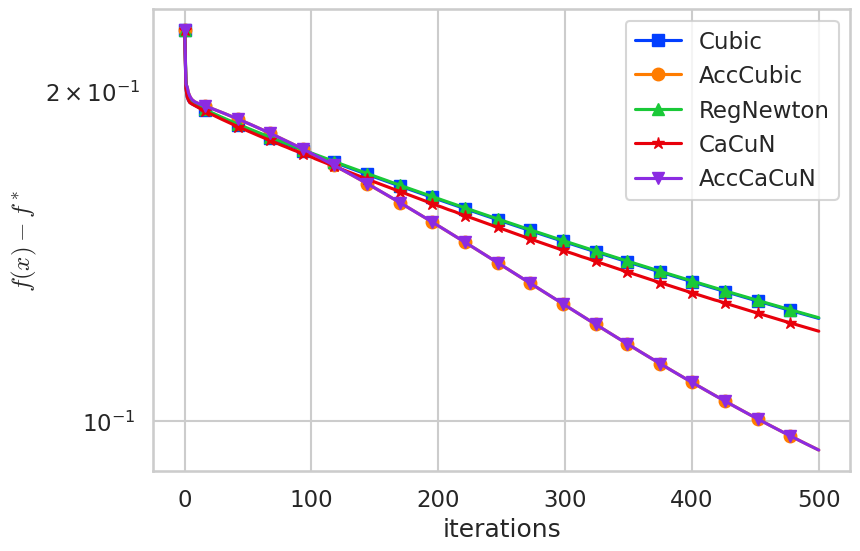

In [94]:
cubic = Cubic(loss=loss, label='Cubic')
acccubic = AccCubic(loss=loss, label='AccCubic')

regn = RegNewton(loss=loss, adaptive=False, use_line_search=False, label='RegNewton')

cacun = CaCuN(loss=loss, label='CaCuN')
acccacun = AccCaCuN(loss=loss, label='AccCaCuN')

optimizers = [cubic, acccubic, regn, cacun, acccacun]

it_max = 500
time=False
for opt in optimizers:
    print(f'Running optimizer: {opt.label}')
    %time opt.run(x0=x0, it_max=it_max)
    opt.compute_loss_of_iterates()

for opt, marker in zip(optimizers, markers):
    opt.trace.plot_losses(marker=marker)
plt.yscale('log')
plt.legend()
plt.savefig(f'logistic_{dataset}_cacun_{"t" if time == True else "i"}.pdf', bbox_inches='tight')

self.reg_coef=np.float64(18172985072.20507)
Running optimizer: Cubic
CPU times: user 1h 22min 21s, sys: 11.7 s, total: 1h 22min 33s
Wall time: 1min 40s
Running optimizer: AccCubic
CPU times: user 1h 24min 7s, sys: 10.4 s, total: 1h 24min 17s
Wall time: 1min 40s
Running optimizer: RegNewton
CPU times: user 1h 21min 29s, sys: 11.8 s, total: 1h 21min 41s
Wall time: 1min 40s
Running optimizer: CaCuN
CPU times: user 1h 31min 47s, sys: 7.22 s, total: 1h 31min 54s
Wall time: 1min 40s
Running optimizer: AccCaCuN
CPU times: user 1h 31min 53s, sys: 7.5 s, total: 1h 32min 1s
Wall time: 1min 40s


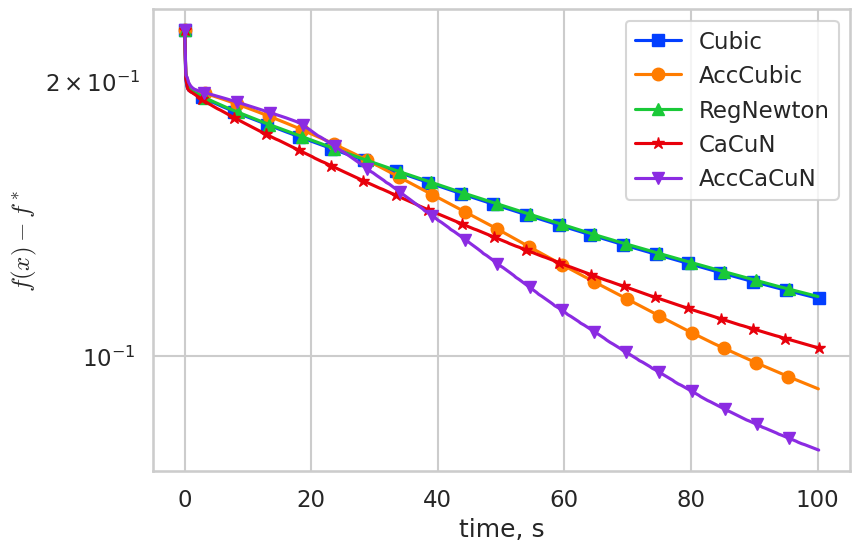

In [93]:
cubic = Cubic(loss=loss, label='Cubic')
acccubic = AccCubic(loss=loss, label='AccCubic')

regn = RegNewton(loss=loss, adaptive=False, use_line_search=False, label='RegNewton')

cacun = CaCuN(loss=loss, label='CaCuN')
acccacun = AccCaCuN(loss=loss, label='AccCaCuN')

optimizers = [cubic, acccubic, regn, cacun, acccacun]

time=True
t_max = 100
for opt in optimizers:
    print(f'Running optimizer: {opt.label}')
    %time opt.run(x0=x0, t_max=t_max)
    opt.compute_loss_of_iterates()

for opt, marker in zip(optimizers, markers):
    opt.trace.plot_losses(marker=marker, time=time, use_ls_its=False)
plt.yscale('log')
plt.legend()
plt.savefig(f'logistic_{dataset}_cacun_{"t" if time == True else "i"}.pdf', bbox_inches='tight')

In [ ]:
dataset = 'w8a'
A, b = get_dataset(dataset)

n, dim = A.shape
# A = A.astype(np.float64, copy=False)

loss = LogisticRegression(A, b, l1=0, l2=0)

x0 = np.zeros(dim)
# loss.f_opt = SuperCubic(loss=loss, label='super').run(x0, it_max=40000)
fopt=np.float64(0.1108110124131768)

The passed labels have values in the set {-1, 1}. Changing them to {0, 1}


self.reg_coef=np.float64(2.7172711630214916)
Running optimizer: Cubic
CPU times: user 27min 2s, sys: 55.5 s, total: 27min 58s
Wall time: 1min 51s
Running optimizer: AccCubic
CPU times: user 27min 3s, sys: 55.5 s, total: 27min 58s
Wall time: 1min 51s
Running optimizer: RegNewton
CPU times: user 35.2 s, sys: 19.8 s, total: 55 s
Wall time: 55 s
Running optimizer: CaCuN
CPU times: user 3.27 s, sys: 0 ns, total: 3.27 s
Wall time: 3.27 s
Running optimizer: AccCaCuN
CPU times: user 3.28 s, sys: 0 ns, total: 3.28 s
Wall time: 3.28 s


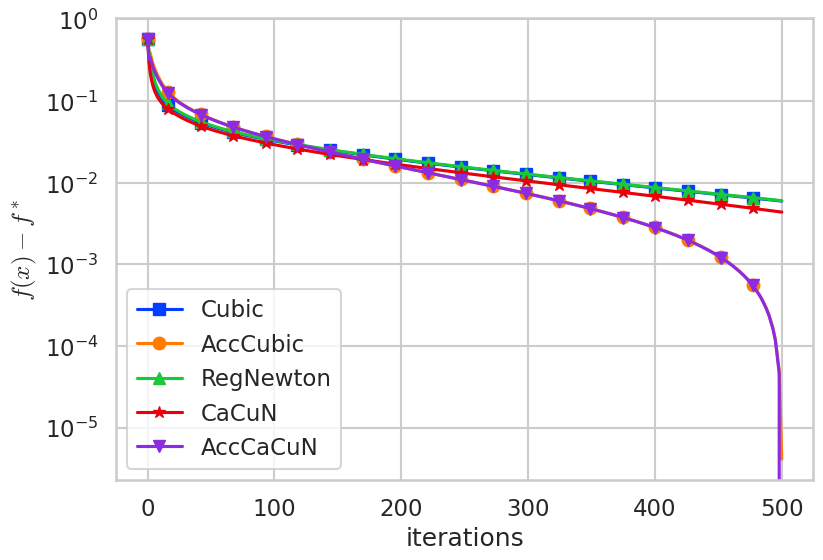

In [98]:
cubic = Cubic(loss=loss, label='Cubic')
acccubic = AccCubic(loss=loss, label='AccCubic')

regn = RegNewton(loss=loss, adaptive=False, use_line_search=False, label='RegNewton')

cacun = CaCuN(loss=loss, label='CaCuN')
acccacun = AccCaCuN(loss=loss, label='AccCaCuN')

optimizers = [cubic, acccubic, regn, cacun, acccacun]

time=False
it_max = 500
for opt in optimizers:
    print(f'Running optimizer: {opt.label}')
    %time opt.run(x0=x0, it_max=it_max)
    opt.compute_loss_of_iterates()

for opt, marker in zip(optimizers, markers):
    opt.trace.plot_losses(marker=marker)
plt.yscale('log')
plt.legend()
plt.savefig(f'logistic_{dataset}_cacun_{"t" if time == True else "i"}.pdf', bbox_inches='tight')

self.reg_coef=np.float64(2.7172711630214916)
Running optimizer: Cubic
CPU times: user 4min 50s, sys: 9.99 s, total: 5min
Wall time: 20.1 s
Running optimizer: AccCubic
CPU times: user 4min 50s, sys: 10.1 s, total: 5min
Wall time: 20.2 s
Running optimizer: RegNewton
CPU times: user 12.9 s, sys: 7.21 s, total: 20.1 s
Wall time: 20.1 s
Running optimizer: CaCuN
CPU times: user 20 s, sys: 0 ns, total: 20 s
Wall time: 20 s
Running optimizer: AccCaCuN
CPU times: user 20 s, sys: 0 ns, total: 20 s
Wall time: 20 s


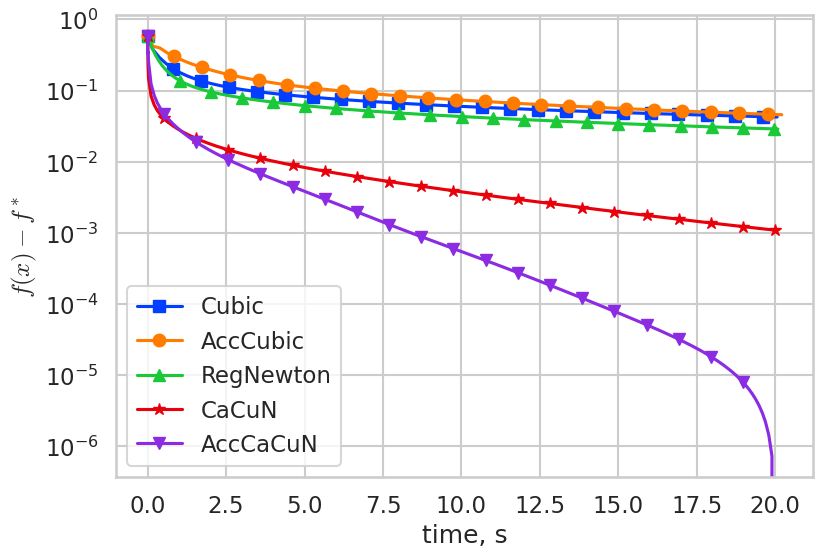

In [99]:
cubic = Cubic(loss=loss, label='Cubic')
acccubic = AccCubic(loss=loss, label='AccCubic')

regn = RegNewton(loss=loss, adaptive=False, use_line_search=False, label='RegNewton')

cacun = CaCuN(loss=loss, label='CaCuN')
acccacun = AccCaCuN(loss=loss, label='AccCaCuN')

optimizers = [cubic, acccubic, regn, cacun, acccacun]

time=True
t_max = 20
for opt in optimizers:
    print(f'Running optimizer: {opt.label}')
    %time opt.run(x0=x0, t_max=t_max)
    opt.compute_loss_of_iterates()

for opt, marker in zip(optimizers, markers):
    opt.trace.plot_losses(marker=marker, time=time)
plt.yscale('log')
plt.legend()
plt.savefig(f'logistic_{dataset}_cacun_{"t" if time == True else "i"}.pdf', bbox_inches='tight')

In [ ]:
dataset = 'mushrooms'
A, b = get_dataset(dataset)

n, dim = A.shape
# A = A.astype(np.float64, copy=False)
# A /= A.max()

loss = LogisticRegression(A, b, l1=0, l2=0)

x0 = np.zeros(dim)
loss.f_opt = SuperCubic(loss=loss, label='super').run(x0, it_max=40000)
# fopt=np.float64(0.1108110124131768)

The passed labels have values in the set {1, 2}. Changing them to {0, 1}
fopt=np.float64(2.772122812435447e-18)


self.reg_coef=np.float64(4.56165313336437)
Running optimizer: Cubic
CPU times: user 3min 17s, sys: 0 ns, total: 3min 17s
Wall time: 8.32 s
Running optimizer: AccCubic
CPU times: user 3min 28s, sys: 7.52 ms, total: 3min 28s
Wall time: 8.56 s
Running optimizer: RegNewton
CPU times: user 3.46 s, sys: 0 ns, total: 3.46 s
Wall time: 3.46 s
Running optimizer: CaCuN
CPU times: user 4.77 s, sys: 159 μs, total: 4.77 s
Wall time: 680 ms
Running optimizer: AccCaCuN
CPU times: user 559 ms, sys: 0 ns, total: 559 ms
Wall time: 559 ms


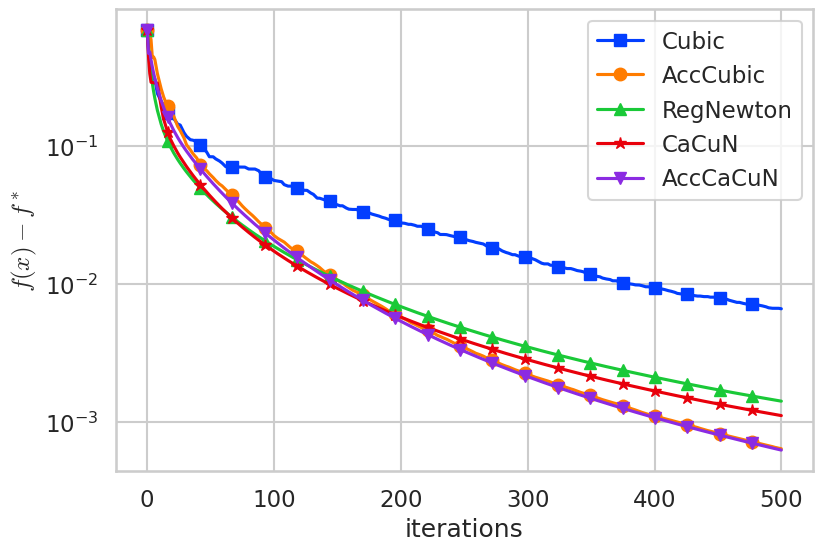

In [106]:
cubic = Cubic(loss=loss, label='Cubic')
acccubic = AccCubic(loss=loss, label='AccCubic')

regn = RegNewton(loss=loss, adaptive=False, use_line_search=False, label='RegNewton')

cacun = CaCuN(loss=loss, label='CaCuN')
acccacun = AccCaCuN(loss=loss, label='AccCaCuN')

optimizers = [cubic, acccubic, regn, cacun, acccacun]

time=False
it_max = 500
for opt in optimizers:
    print(f'Running optimizer: {opt.label}')
    %time opt.run(x0=x0, it_max=it_max)
    opt.compute_loss_of_iterates()

for opt, marker in zip(optimizers, markers):
    opt.trace.plot_losses(marker=marker)
plt.yscale('log')
plt.legend()
plt.savefig(f'logistic_{dataset}_cacun_{"t" if time == True else "i"}.pdf', bbox_inches='tight')

self.reg_coef=np.float64(4.56165313336437)
Running optimizer: Cubic
CPU times: user 11min 57s, sys: 13.6 ms, total: 11min 58s
Wall time: 30 s
Running optimizer: AccCubic
CPU times: user 11min 51s, sys: 25.4 ms, total: 11min 51s
Wall time: 30 s
Running optimizer: RegNewton
CPU times: user 30.5 s, sys: 19.2 ms, total: 30.6 s
Wall time: 30 s
Running optimizer: CaCuN
CPU times: user 34.1 s, sys: 10.3 ms, total: 34.1 s
Wall time: 30 s
Running optimizer: AccCaCuN
CPU times: user 30 s, sys: 9.96 ms, total: 30 s
Wall time: 30 s


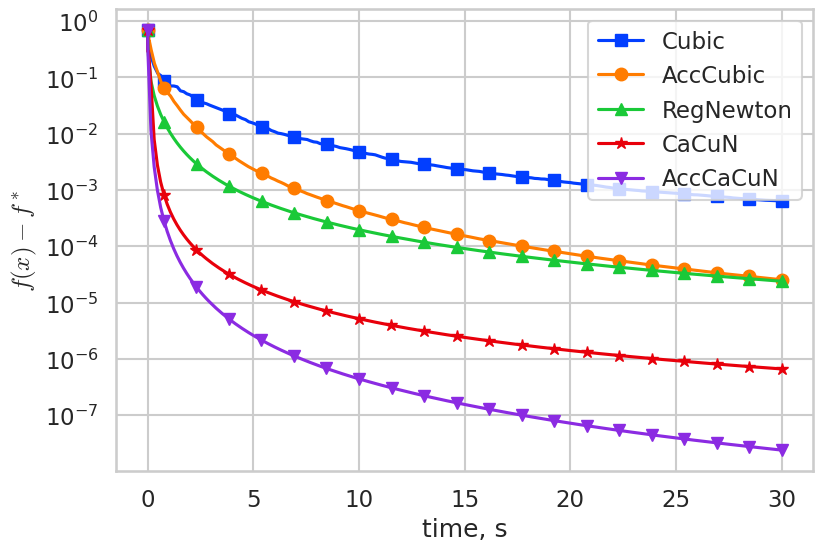

In [107]:
cubic = Cubic(loss=loss, label='Cubic')
acccubic = AccCubic(loss=loss, label='AccCubic')

regn = RegNewton(loss=loss, adaptive=False, use_line_search=False, label='RegNewton')

cacun = CaCuN(loss=loss, label='CaCuN')
acccacun = AccCaCuN(loss=loss, label='AccCaCuN')

optimizers = [cubic, acccubic, regn, cacun, acccacun]

time=True
t_max = 30
for opt in optimizers:
    print(f'Running optimizer: {opt.label}')
    %time opt.run(x0=x0, t_max=t_max)
    opt.compute_loss_of_iterates()

for opt, marker in zip(optimizers, markers):
    opt.trace.plot_losses(marker=marker, time=time)
plt.yscale('log')
plt.legend()
plt.savefig(f'logistic_{dataset}_cacun_{"t" if time == True else "i"}.pdf', bbox_inches='tight')

## LogSumExp

In [108]:
n, dim = 2000, 1400
n, dim = 500, 200
least_squares_term = False
max_smoothing = 0.05
l2 = 0.0
loss = LogSumExp(n=n, dim=dim, least_squares_term=least_squares_term, l2=l2, max_smoothing=max_smoothing)
# x0 = rng.normal(scale=0.5, size=dim)
x0 = np.ones(dim)
loss.f_opt = SuperCubic(loss=loss, label='super').run(x0, it_max=40000)

fopt=np.float64(4.135211534756795)


self.reg_coef=np.float64(17000731.095493045)
Running optimizer: Cubic
CPU times: user 15min 27s, sys: 47.8 ms, total: 15min 27s
Wall time: 29 s
Running optimizer: AccCubic
CPU times: user 16min 6s, sys: 58.5 ms, total: 16min 6s
Wall time: 30.2 s
Running optimizer: RegNewton
CPU times: user 38.4 s, sys: 0 ns, total: 38.4 s
Wall time: 1.21 s
Running optimizer: CaCuN
CPU times: user 3.28 s, sys: 539 μs, total: 3.28 s
Wall time: 362 ms
Running optimizer: AccCaCuN
CPU times: user 362 ms, sys: 20 ms, total: 382 ms
Wall time: 370 ms


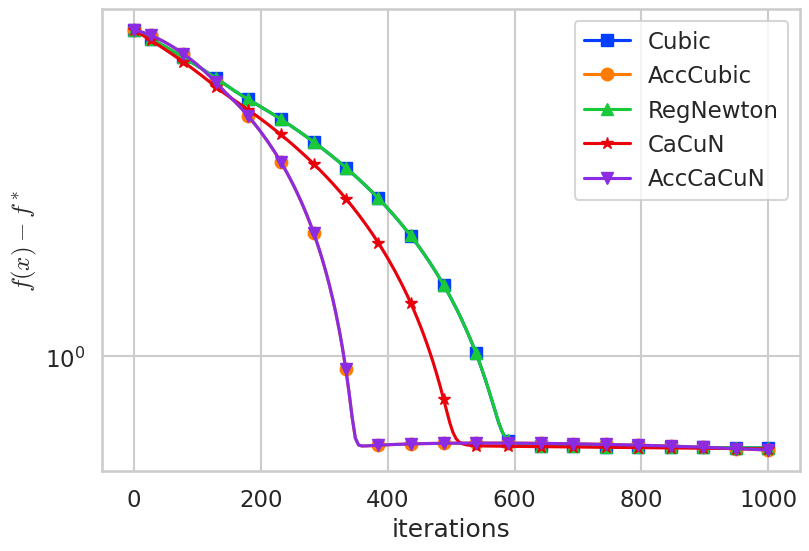

In [113]:
cubic = Cubic(loss=loss, label='Cubic')
acccubic = AccCubic(loss=loss, label='AccCubic')

regn = RegNewton(loss=loss, adaptive=False, use_line_search=False, label='RegNewton')

cacun = CaCuN(loss=loss, label='CaCuN')
acccacun = AccCaCuN(loss=loss, label='AccCaCuN')

optimizers = [cubic, acccubic, regn, cacun, acccacun]

time=False
it_max = 1000
for opt in optimizers:
    print(f'Running optimizer: {opt.label}')
    %time opt.run(x0=x0, it_max=it_max)
    opt.compute_loss_of_iterates()

for opt, marker in zip(optimizers, markers):
    opt.trace.plot_losses(marker=marker)
plt.yscale('log')
plt.legend()
plt.savefig(f'logsumexp_{n,dim,max_smoothing}_cacun_{"t" if time == True else "i"}.pdf', bbox_inches='tight')

self.reg_coef=np.float64(17000731.095493045)
Running optimizer: Cubic
CPU times: user 10min 40s, sys: 38.3 ms, total: 10min 40s
Wall time: 20 s
Running optimizer: AccCubic
CPU times: user 10min 39s, sys: 39.1 ms, total: 10min 39s
Wall time: 20 s
Running optimizer: RegNewton
CPU times: user 10min 40s, sys: 49.1 ms, total: 10min 40s
Wall time: 20 s
Running optimizer: CaCuN
CPU times: user 23.2 s, sys: 453 ms, total: 23.6 s
Wall time: 20 s
Running optimizer: AccCaCuN
CPU times: user 20 s, sys: 391 ms, total: 20.4 s
Wall time: 20 s


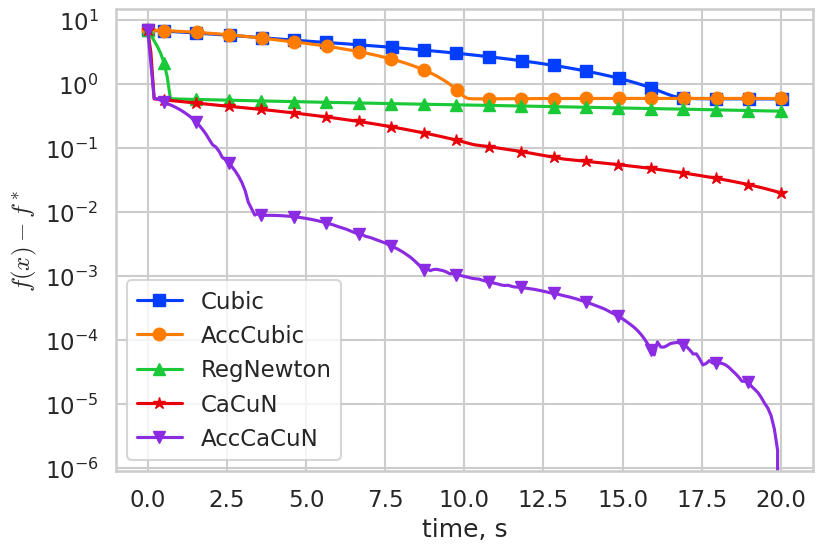

In [114]:
cubic = Cubic(loss=loss, label='Cubic')
acccubic = AccCubic(loss=loss, label='AccCubic')

regn = RegNewton(loss=loss, adaptive=False, use_line_search=False, label='RegNewton')

cacun = CaCuN(loss=loss, label='CaCuN')
acccacun = AccCaCuN(loss=loss, label='AccCaCuN')

optimizers = [cubic, acccubic, regn, cacun, acccacun]

time=True
t_max = 20
for opt in optimizers:
    print(f'Running optimizer: {opt.label}')
    %time opt.run(x0=x0, t_max=t_max)
    opt.compute_loss_of_iterates()

for opt, marker in zip(optimizers, markers):
    opt.trace.plot_losses(marker=marker, time=time)
plt.yscale('log')
plt.legend()
plt.savefig(f'logsumexp_{n,dim,max_smoothing}_cacun_{"t" if time == True else "i"}.pdf', bbox_inches='tight')